#Часть 1

In [1]:
!apt-get update
!apt-get install mummer

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,998 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,964 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Get:14 

In [10]:
!pip install biopython seaborn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.0 MB/s eta 0:00:00


In [2]:
!mkdir -p data results
!wget -O data/ecoli_k12.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
!wget -O data/ecoli_o157.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"
!gunzip data/*.fna.gz

--2026-04-09 22:02:02--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1379902 (1.3M) [application/x-gzip]
Saving to: ‘data/ecoli_k12.fna.gz’

data/ecoli_k12.fna. 100%[===================>]   1.32M  8.49MB/s    in 0.2s    

2026-04-09 22:02:03 (8.49 MB/s) - ‘data/ecoli_k12.fna.gz’ saved [1379902/1379902]

--2026-04-09 22:02:03--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP re

In [3]:
# 1. Запускаем оптимизированное выравнивание геномов
!nucmer --prefix=results/ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12 data/ecoli_k12.fna data/ecoli_o157.fna

# 2. Фильтруем результаты (оставляем только лучшие выравнивания 1-to-1)
!delta-filter -1 results/ecoli_opt.delta > results/ecoli_opt_filt.delta

# 3. Извлекаем SNP в удобном табличном формате
!show-snps -C -T results/ecoli_opt_filt.delta > results/snps.tsv

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "results/ecoli_opt.ntref" of length 4641653
# construct suffix tree for sequence of length 4641653
# (maximum reference length is 536870908)
# (maximum query length is 4294967295)
# process 46416 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /usr/bin/mummer results/ecoli_opt.ntref 3.00
# reading input file "/content/data/ecoli_o157.fna" of length 5594607
# matching query-file "/content/data/ecoli_o157.fna"
# against subject-file "results/ecoli_opt.ntref"
# COMPLETETIME /usr/bin/mummer results/ecoli_opt.ntref 11.84
# SPACE /usr/bin/mummer results/ecoli_opt.ntref 9.90
4: FINISHING DATA


In [15]:
# Переходим в директорию data (если она есть) или убеждаемся, что качаем куда надо
!wget -P data/ "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"

# Распаковываем скачанный архив
!gunzip data/GCF_000005845.2_ASM584v2_genomic.gbff.gz

--2026-04-09 22:17:52--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3423602 (3.3M) [application/x-gzip]
Saving to: ‘data/GCF_000005845.2_ASM584v2_genomic.gbff.gz’

GCF_000005845.2_ASM 100%[===================>]   3.26M  16.3MB/s    in 0.2s    

2026-04-09 22:17:52 (16.3 MB/s) - ‘data/GCF_000005845.2_ASM584v2_genomic.gbff.gz’ saved [3423602/3423602]



In [16]:
import pandas as pd

snps_df = pd.read_csv('results/snps.tsv', sep='\t', skiprows=4, header=None)

snps_df.columns = ['P1', 'SUB1', 'SUB2', 'P2', 'BUFF', 'DIST', 'LEN_R', 'LEN_Q', 'REF_CONTIG', 'QUERY_CONTIG']

display(snps_df.head())

,P1,SUB1,SUB2,P2,BUFF,DIST,LEN_R,LEN_Q,REF_CONTIG,QUERY_CONTIG
0,58,G,C,58,6,58,1,1,NC_000913.3,NC_002695.2
1,64,T,C,64,6,64,1,1,NC_000913.3,NC_002695.2
2,228,.,A,229,0,228,1,1,NC_000913.3,NC_002695.2
3,228,.,C,230,0,228,1,1,NC_000913.3,NC_002695.2
4,228,.,C,231,0,228,1,1,NC_000913.3,NC_002695.2


Столбцы файла SNP:

P1: Позиция SNP в референсном геноме (E. coli K-12).

SUB1: Нуклеотидное основание в референсном геноме (символ . означает инсерцию в референс).

SUB2: Нуклеотидное основание в геноме запроса (E. coli O157:H7) (символ . означает делецию в запросе).

P2: Позиция SNP в геноме запроса.

BUFF: Расстояние (в нуклеотидах) от данного SNP до ближайшего соседнего несовпадения (mismatch) или конца выравнивания.

DIST: Расстояние (в нуклеотидах) от данного SNP до ближайшего конца последовательности (контига).

LEN_R: Длина референсного контига/хромосомы.

LEN_Q: Длина контига/хромосомы запроса.

REF_CONTIG: Идентификатор (название) последовательности референсного генома.

QUERY_CONTIG: Идентификатор (название) последовательности генома запроса.

#Часть 2

In [21]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
gbk_file = "data/GCF_000005845.2_ASM584v2_genomic.gbff"
snp_file = "results/snps.tsv"

# Чтение SNP файла
snps_df = pd.read_csv(snp_file, sep='\t', header=None, skiprows=4)
snps_df.columns = ['p1', 'sub1', 'sub2', 'p2', 'buff', 'dist', 'len_r', 'len_q', 'ref_contig', 'query_contig']

# Чтение GenBank файла
record = SeqIO.read(gbk_file, "genbank")

# 2. Логика аннотации
annotations = []

for index, row in snps_df.iterrows():
    snp_pos = int(row['p1']) - 1
    ref_nuc = row['sub1']
    alt_nuc = row['sub2']

    # Проверяем, не является ли вариация инделом (вставкой/делецией)
    is_indel = (ref_nuc == '.' or alt_nuc == '.')

    in_gene = False
    for feature in record.features:
        if feature.type == "CDS" and snp_pos in feature.location:
            in_gene = True
            gene_name = feature.qualifiers.get('gene', ['Unknown'])[0]
            locus_tag = feature.qualifiers.get('locus_tag', ['Unknown'])[0]

            if is_indel:
                annotations.append({
                    'pos': snp_pos + 1, 'gene': gene_name, 'locus': locus_tag,
                    'region': 'CDS', 'type': 'Indel', 'aa_change': 'Frameshift',
                    'functional_significance': 'High (Potential gene disruption)'
                })
                break

            strand = feature.location.strand
            gene_seq = feature.location.extract(record.seq)

            # Расчет позиции внутри гена
            if strand == 1:
                pos_in_gene = int(snp_pos - feature.location.start)
            else:
                pos_in_gene = int(feature.location.end - 1 - snp_pos)

            if pos_in_gene < 0 or pos_in_gene >= len(gene_seq):
                annotations.append({
                    'pos': snp_pos + 1, 'gene': gene_name, 'locus': locus_tag,
                    'region': 'CDS', 'type': 'Complex/Pseudogene', 'aa_change': 'N/A',
                    'functional_significance': 'Requires manual check'
                })
                break

            codon_pos = pos_in_gene % 3
            codon_start = pos_in_gene - codon_pos

            old_codon = str(gene_seq[codon_start:codon_start+3])

            # Создаем мутировавший кодон
            new_gene_seq = list(gene_seq)
            if strand == 1:
                new_gene_seq[pos_in_gene] = alt_nuc
            else:
                new_gene_seq[pos_in_gene] = str(Seq(alt_nuc).complement())
            new_codon = "".join(new_gene_seq[codon_start:codon_start+3])

            # Транслируем
            try:
                old_aa = str(Seq(old_codon).translate())
                new_aa = str(Seq(new_codon).translate())

                if old_aa == new_aa:
                    snp_type = "Synonymous"
                    aa_change = f"p.{old_aa}{int(pos_in_gene/3) + 1}{old_aa}"
                    functional = "Low (Silent)"
                else:
                    snp_type = "Nonsynonymous"
                    aa_change = f"p.{old_aa}{int(pos_in_gene/3) + 1}{new_aa}"
                    functional = "Potential impact on protein structure/function"
            except:
                 snp_type = "Error"
                 aa_change = "N/A"
                 functional = "N/A"

            annotations.append({
                'pos': snp_pos + 1, 'gene': gene_name, 'locus': locus_tag,
                'region': 'CDS', 'type': snp_type, 'aa_change': aa_change,
                'functional_significance': functional
            })
            break

    if not in_gene:
        # Если это межгенный регион
        snp_type = 'Indel' if is_indel else 'Intergenic'
        annotations.append({
            'pos': snp_pos + 1, 'gene': 'Intergenic', 'locus': 'N/A',
            'region': 'Intergenic', 'type': snp_type, 'aa_change': 'N/A',
            'functional_significance': 'Potential regulatory impact'
        })

ann_df = pd.DataFrame(annotations)

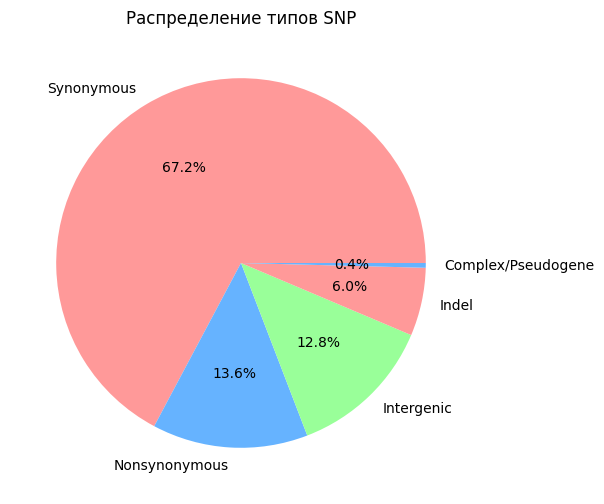

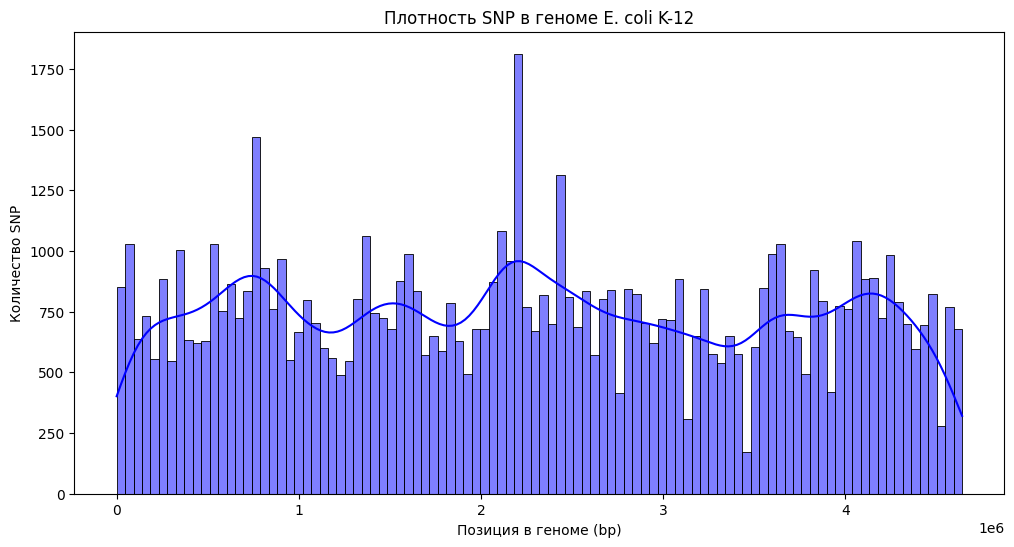

Топ-10 генов с наибольшим количеством SNP:
gene
ybgQ    437
yehB    301
yeeJ    250
ybgO    225
rhsD    217
yehI    194
yjgL    187
ybgP    179
ydbA    166
afuC    153
Name: count, dtype: int64


In [22]:
# Диаграмма распределения типов SNP [cite: 11]
plt.figure(figsize=(8, 6))
ann_df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Распределение типов SNP')
plt.ylabel('')
plt.show()

# График плотности SNP [cite: 11]
plt.figure(figsize=(12, 6))
sns.histplot(ann_df['pos'], bins=100, kde=True, color='blue')
plt.title('Плотность SNP в геноме E. coli K-12')
plt.xlabel('Позиция в геноме (bp)')
plt.ylabel('Количество SNP')
plt.show()

# Топ-10 генов с наибольшим количеством SNP [cite: 12]
top_10_genes = ann_df[ann_df['gene'] != 'Intergenic']['gene'].value_counts().head(10)
print("Топ-10 генов с наибольшим количеством SNP:")
print(top_10_genes)

#Часть 3

Применение результатов полногеномного выравнивания в реальной жизни:

Сравнительная геномика и поиск полиморфизмов (SNP) имеют колоссальное практическое значение в различных сферах:


Эпидемиология (отслеживание вспышек инфекций): Как показал пример со вспышкой листериоза в США, секвенирование и выравнивание геномов изолятов пациентов на референсный геном позволяет за 48 часов (вместо нескольких недель) выявить единый кластер на основе SNP и точно определить источник заражения (в том случае — продукцию конкретного завода).


Медицинская генетика и персонализированная медицина: Сравнение генома раковой опухоли пациента с его нормальной тканью позволяет выявить соматические мутации и структурные перестройки. Например, обнаружение инверсии в гене EML4-ALK позволяет назначить пациенту эффективную таргетную терапию, что приводит к ремиссии. Кроме того, анализ SNP в генах резистентности у бактерий помогает быстро понять, к каким антибиотикам устойчив штамм пациента, и подобрать правильное лечение.

Биотехнология и промышленность: Выравнивание геномов промышленных штаммов бактерий помогает выявить генетические вариации (например, количество копий гена), ответственные за их продуктивность. Это позволяет отбирать или модифицировать штаммы для более эффективного синтеза полезных веществ, таких как этанол.

Очередная победа Гугл колаба!